In [43]:
import sys
import argparse
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd

import csv
import gzip

import scipy.io
import numpy as np 

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import rc_context
import anndata
import torch

# --- MATPLOTLIB SETTINGS ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc_params = {
    "font.family": "sans-serif", # "text.usetex": True,
    "font.serif" : ['Arial'], # "font.size" : 6,
    "font.weight" : "normal",
    'xtick.labelsize' : 5,
    'ytick.labelsize' : 5,
    'legend.fontsize' : 5,
    'axes.labelsize' : 6,
    'axes.linewidth': 0.8,
    'lines.linewidth' : 1,
    'axes.titlesize' : 7, # figure.titlesize,
    'legend.title_fontsize' : 5
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
    "left"   :     0.2,
    'right' : 1.0,
    'bottom' : 0.15
}

import helper_functions



In [193]:

# --- INIT ---



# which data to use
head_folder = "/".join(os.getcwd().split("/")[:3])
data_head_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint' % head_folder
hvg_to_use = 'prior_knowledge_guided' # 'transformed_X_outlier_variance'
cluster_resolution = 0.05
subcluster_resolution = 0.20


# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % data_head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (data_head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder

# clusters
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)

# SMC clusters
subclustering_folder = '%s/subclustering/res_%s' % (clustering_folder,subcluster_resolution)
subcluster_df_fileout = '%s/smc_subclusters.tsv' % (subclustering_folder)


# settings
use_subclusters = False


# set the cluster column
if use_subclusters:
    clustering_folder = subclustering_folder
    cluster_df_fileout = subcluster_df_fileout



In [194]:
# --- GET UNIQUE CLUSTERS ---


descriptions = ['male aligned bmal1-control',
    'male aligned bmal1-ko',
    'male misaligned bmal1-control',
    'female aligned bmal1-control',
    'female aligned bmal1-ko',
    'female misaligned bmal1-control',
    ]
description_loc_list = [[0,0], [0,1], [0,2], [1,0], [1,1], [1,2]]

# try:
#     clusters = sorted(list(pd.read_table(cluster_df_fileout,index_col=None)['leiden_scvi_cluster'].unique()))
# except:
#     clusters = sorted(list(pd.read_table(cluster_df_fileout,index_col=None)['smc_subcluster'].unique()))
# clusters = list(filter(lambda x: ~np.isnan(x),clusters)) # get rid of NaN cluster (only relevant for SMC subcluster)
# clusters = list(map(lambda x: int(x),clusters))



# ** limit clusters **
if use_subclusters:
    clusters = [0,1,2,3,4]
else:
    clusters = [0,1,2,3]
clusters


[0, 1, 2, 3]

In [195]:
# --- LOAD THE ADATA ---

import anndata
adata = anndata.read_h5ad(adata_path)

adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [196]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')
subcluster_df = pd.read_table(subcluster_df_fileout,sep='\t',index_col='index')


# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]
subcluster_df = subcluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
if use_subclusters:
    adata.obs["cluster"] = np.array(cluster_df['smc_subcluster'])
else:
    adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])
adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [197]:
# --- MAKE THE FOLDER OUTS ---

# head folder
reg_head_folder = '%s/nonparametric_reg' % clustering_folder


# subfolders for each cluster / condition combo
cluster_description_folder_out_dict = {}
for cluster in clusters:
    cluster_reg_folder = '%s/cluster_%s' % (reg_head_folder,cluster)
    for description in descriptions:
        cluster_description_reg_folder = '%s/%s' % (cluster_reg_folder,description)

        # update dict
        if cluster not in cluster_description_folder_out_dict:
            cluster_description_folder_out_dict[cluster] = {}
        cluster_description_folder_out_dict[cluster][description] = cluster_description_reg_folder

    
    

In [198]:
import helper_functions
import importlib
importlib.reload(helper_functions)

gene_set_dict_of_dicts = helper_functions.get_gene_set_dicts(head_folder,reg_genes_to_est=None)




In [199]:
# --- SET CLUSTER ---

cluster = 1



In [200]:
# --- SET THE GENES ---

# genes = gene_set_dict_of_dicts['macrophage_m1_m2']['GSE5099_CLASSICAL_M1_VS_ALTERNATIVE_M2_MACROPHAGE_UP']

# genes = 'MAP2K1;GADD45B;DIABLO;GADD45A;PIK3R1;SEPT4;TUBA4A;GADD45G;NFKBIA;TUBA1A;CTSL;BCL2;CYCS;CTSH;BIRC2'




# genes = 'mmp1; mmp8; mmp13;mmp7;mmp26;mmp12;mmp2;mmp9;mmp20;mmp3;mmp10;mmp11;mmp14;mmp15;mmp16;mmp17;mmp24;mmp25' # 'Mmp9'
# genes = 'NFKBIA;ZBTB16;ITGB3;LEO1;TWIST2;TWIST1'
# genes = 'APP;BTG3;CTCF;IFIT3;DNAJB2;DUSP10;ADAMTS1;BRD7;KLF10;CGREF1;PBRM1;TGFB2;MYOCD;IGFBP5;TGFB3;TESC;ITGA1;CGRRF1;SMAD6;SMARCA2;PTPN14;SKI;FABP3;OGN;CDH13;TRIB1;BMPR1B;HSPA1B;HSPA1A'
# genes = 'CAMK2B;PLVAP;CDKN1A;EPB41;TSC22D3;ANKRD23;IGFBP2;KCNA2;NR1D1;TMEM82;SLC6A6;DBP;TEF;TSPAN9;TCAP;PIM3;SLC25A34;LONRF1'
# genes = 'Timp1;Timp2;Timp3;Timp4'
# genes = 'Cxcl2;Tnf;Ccl7;Ccl4;Cxcl16;Ccl3'
# genes = 'Cdkn1a;Wee1;Atf3'
# genes = 'Id1;Id2;Id3;Id4'
# genes = 'Agtr1;Akt1;Smad1;Smad2;Smad3;Smad4;Smad5;Smad6;Smad7;Smad8;Smad9'
# genes = 'Tuba1a;Tuba1b;Tuba1c;Tuba4a;Tubb2a;Gja1;Gja4'
# genes = 'Atf3;Klf4;Nr4a1;Nr4a2;Nr4a3;Wee1;Cdkn1a'
# genes = 'Hspa1a;Hspa1b'
# genes = 'Ifit3'
# genes = 'Atf3'
# genes = 'Pdk1;Pdk2;Pdk3;Pdk4'
# genes = 'GSTM1;GSTT1;GSTP1;GCLM;GCLC)'
# genes = 'RUNX2;Bmp2'
# genes = 'Uba52;Hes1Notch2;Gja1;Gja4;Hspa1a;Hspa1b;Atf3;Rock1;CSNK2A2;Egln1;Ccn1;Ccn2;Ccn3;Ccn4'
# genes = 'Il10;Cd163;Cd206;RETNLB;arg1;Atf3;Stat6;Hbegf;Tgm2;Lpl;Agpat1;Il1b;Irf7;Ccl12;Bgn;Col3a1;S100a6;S100a8;Retnla;Il6;Ptgs2;Fn1;Id2;Mt2;Dusp2;Mmp14;Mmp9'
# genes = 'Il10;Cd163;Cd206;RETNLB;arg1;Atf3;Stat6'
# genes = 'Nfkb1;Stat1;Klf4;Il1b;Il6;Tnf;Tnfa;Stat6'
# genes = 'Atf6;Cd4b;Ccl4;Cks2;Cstf1;Cxcl2;Dusp22;Egr1;Flii;Fn1;Galnt11;Hcfc1;Hnrnpul1;Idh3g;Impdh2;Klf13;Maff;Nup98;Ric8a;Rnf19a;Sarnp;Sdf2;Sirt1;Xbp;Zfp90'
# genes = 'Egr1;Egr3;Fbln7;Fos;Fosb;Fosl2;Hk2;Id1;Nr4a1;Nr4a3'
# genes = 'Grem1;Grem2;Vcam1;Icam1;Kdm5c;Kdm6a;Casq1;Ghr;Nr4a1;Nr4a2;Nr4a3;Bamp;Carmn;Ccn1;Ccn2;Ccn3;Ar;Timp4;Smad6;Smad7;Cfh;Mt1;Mt2;Vldlr;Wif;Lars2;Pecam1;Ptgs2;Atf3;Id1;Id2;Id3;Id4'
# genes = 'Nr4a1;Nr4a2;Nr4a3'
# genes = 'GDF10;TGFB1;CXCL12;TNFRSF11B;IL6ST;OSMR;CX3CL1;TNFRSF1A'
# genes = 'COL1A1;CD63;TGFB1;COL1A2;LUM;CTSL;MMP2;FN1;SDC1;TIMP3;THBS1;DCN'
# genes = 'Rgs5'
# genes = 'FOSB;NR4A1;NR4A2;EGR3;NR4A3'
# genes = 'Spp1;Crabp2;Emp1;Mdk;Col1a1;Timp3;Abca1;Serping1;Ctgf;Cebpnb;Bsg'
# genes = 'IL1B;NEDD4;ARNT;FAM129B'

# genes = 'Tnfrsf11b;Gdf10;Cx3cl1;Osmr;Lum;Mmp2;Thbs1;Dcn;Vcam1;Ly6a'
# genes = 'Id1'
# genes = 'Egr3;Fabp4'


# ** previous Garret bulk genes **

# glycolytic genes cycled out of phase with gluconeogenesis / glycogenolysis

# cholesterol / fatty acid biosynthesis out of phase with enzymes in lipolysis and B-oxidation of fatty acids
# genes = 'Gpi1;Pgam2'

# enzymes of the hexose monophosphate shunt, which links glycolysis and gluconeogenesis
# genes = 'Pck1;Cebpb;Atf2;Atf3'

# lipid biosynthetic pathway genes
# genes = 'Gnpat;Agpat3;Dgat1;Scd2;Mte1;Fpps;Mvd;Ipp;Nsdh1'

# lipolytic genes
# genes = 'Scd;Cpt1;Ppara'

# contractile
# genes = 'Acta2;Tagln;Tcap;Cnn1;Tpm1'

# junctional adhesion
# genes = 'F11r;Cldn5;Icam2;Glycam1'

# genes = 'hspa1a;hspa1b;hspa1l;HSPA6'
# genes = 'Gja4;Gja1'
# genes = 'Smad1;Smad2;Smad3;Smad4;Smad5;Smad6;Smad7;Smad8;Smad9'
# genes = 'Grem1;Grem2'
# genes = 'CTSA;ABCA2;ATP6AP1;FUCA1;HEXB;HEXA;LIPA;LAMP1;NAGLU;GM2A;'
# genes = 'Ccn1;Ccn2;Ccn3'

# M1 genes
# genes = 'Ptgs2;Ccr2;IL1b;Il6;IL12;IL23;Cd80;Cd86;Nfkb1;Stat1;Stat3;Irf4;Hif1a;Ap1'
# genes = gene_set_dict_of_dicts['macrophage_m1_m2']['GSE5099_CLASSICAL_M1_VS_ALTERNATIVE_M2_MACROPHAGE_UP']

# M2 genes
# genes = 'Il10;Tgfb1;Tgfb2'


# ---- Endothelial ----

# ** M-F differences in alignment **

# focal adhesion
# genes = 'COL1A1;COL1A2;PPP1R12A;ACTN1;ITGA8;PPP1R12B;THBS1;MYLK'

# adherens junctions
# genes = gene_set_dict_of_dicts['KEGG_2019_Mouse']['Adherens junction']

# tihgt junctions
# genes = gene_set_dict_of_dicts['KEGG_2019_Mouse']['Tight junction']


genes = 'PALLD;Acta2;Myh11;Vim'


# ---- Fibroblast ----

# ** M-F differences in alignment **

# focal adhesion
# genes = 'LAMC3;LAMB2;ACTN1;ITGA1;PIK3R1;MYLK;COMP;CCND2;CCND1;COL4A2;COL4A1;COL4A4;COL4A3;ZYX;PIP5K1C;PPP1R12B;BIRC3;ITGA9'




# ---- MACROPHAGE ----

# ** M-F differences in alignment **

# MAPK
# genes = 'ATF2;MAPK9;RPS6KA5;PDGFB;HSPB1;MAP3K8;RELB;RASGRP3'





# --- CONVERT ---

# convert from string list to list
genes = genes.split(";")
genes = list(map(lambda x: x.lower().capitalize(), genes))
genes




# genes = ['FOSB',
#     'NR4A1',
#     'NR4A2',
#     'EGR3',
#     'NR4A3',
#     'ARC',
#     'XIRP1',
#     'RRAD',
#     'RASL11A',
#     'FOS',
#     'IL24',
#     'RGS16',
#     'SIK1',
#     'BTG2',
#     'ATF3',
#     'DUSP2',
#     'EGR1',
#     'FMO2']
# genes = list(map(lambda x: x.lower().capitalize(), genes))



# ** temp: set gene list **

# genes = list(filter(lambda x: "Gj" == x[:2], adata.var_names))
# genes = ['Gja4', 'Gja6', 'Gja1']







['Palld', 'Acta2', 'Myh11', 'Vim']

In [201]:
# # --- LOAD GENE SET FROM FILE ---

# # path = "/Users/mingyaolab/Dropbox/athero_data/preprocessed/RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_scale_True_zero-centered_True_scale-per-batch_False_sample-min-disp_3.0_zsgreen-min_disp_3.0_all-min-disp_0.7/desc_results/subject_RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_dims_128_resolution_0.35_tol_0.005_run_0/pseudotime_X_velocity_results/pseudotime-col_pseudotime_2_batch-subset_['RPS007']_num-bins_4_bin-subset_[0, 1, 2]_p-val_thresh_0.05/gene_patterns/up_down.txt"
# path = "/Users/mingyaolab/Dropbox/athero_data/preprocessed/RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_scale_True_zero-centered_True_scale-per-batch_False_sample-min-disp_3.0_zsgreen-min_disp_3.0_all-min-disp_0.7/desc_results/subject_RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_dims_128_resolution_0.35_tol_0.005_run_0/pseudotime_X_velocity_results/pseudotime-col_pseudotime_2_batch-subset_['RPS007']_num-bins_4_bin-subset_[0, 1, 2]_p-val_thresh_0.05/gene_patterns/down_down.txt"
# genes = list(pd.read_table(path,header=None).iloc[:,0])
# genes




In [202]:
# # --- LOAD GENE SET FROM FILE ---

# path = '/Users/mingyaolab/Dropbox/aorta_circadian_data/gene_sets/quertermous_smc_pdgf_stim_de_genes.xlsx'
# genes = np.array(pd.read_excel(path,header=2)['GeneID'])
# genes = genes[:-2]
# genes = list(map(lambda x: x.lower().capitalize(), genes))
# genes




In [203]:
# # up-up
# smc_switching_down_down_path = "/Users/mingyaolab/Dropbox/athero_data/preprocessed/RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_scale_True_zero-centered_True_scale-per-batch_False_sample-min-disp_3.0_zsgreen-min_disp_3.0_all-min-disp_0.7/desc_results/subject_RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_dims_128_resolution_0.35_tol_0.005_run_0/pseudotime_X_velocity_results/pseudotime-col_pseudotime_2_batch-subset_['RPS007']_num-bins_4_bin-subset_[0, 1, 2, 3]_p-val_thresh_0.05/gene_patterns/up_up.txt"
# with open(smc_switching_down_down_path) as file_obj:
#     genes = list(map(lambda x: x.replace('\n',""), file_obj.readlines()))


# # klf4 targets after HFD   
# path = '/Users/mingyaolab/Dropbox/aorta_circadian_data/gene_sets/oct4_smc_chip.tsv'
# genes = np.array(pd.read_table(path,header=None,sep='\t').iloc[:,0])
# genes = list(map(lambda x: x.lower().capitalize(), genes))

    
    
    

In [204]:
# # --- TEMP ---

# genes = 'TGFB1	TGFB3	TGFB2	ZBTB17	CDC25A	TRP53	CDC25B	RBX1	CDC20	CDC25C	BUB1B	CDC16	MAD2L1	MAD2L2	PCNA	RB1	CCNH	CDC23	CCND3	FZR1	CCND2	CHEK1	CDC26	CCND1	CDC27	E2F1	CHEK2	PTTG1	MYC	E2F2	E2F3	E2F4	E2F5	SMAD3	CREBBP	SMAD2	SMAD4	PLK1	GADD45B	GADD45A	GADD45G	CCNA2	STAG1	CCNA1	TFDP1	STAG2	TFDP2	MAD1L1	MDM2	ANAPC13	CUL1	CDC14A	PRKDC	PKMYT1	ANAPC10	ANAPC11	CDC14B	SMC3	CCNB3	CCNB2	CCNB1	ABL1	SFN	SKP2	CDC7	CDC6	SMC1B	SMC1A	RBL1	RBL2	CDK7	CDK6	ESPL1	CDK4	CDK2	MCM4	MCM5	ATM	CDK1	MCM6	MCM7	MCM2	ATR	MCM3	YWHAG	GSK3B	YWHAE	YWHAB	ORC6	RAD21	ORC5	ORC2	ORC1	ORC4	YWHAQ	ORC3	YWHAH	CDKN2C	CDKN2D	CDKN2A	CDKN2B	YWHAZ	WEE1	WEE2	DBF4	CCNE2	CCNE1	ANAPC4	ANAPC5	ANAPC7	ANAPC1	ANAPC2	CDKN1B	CDKN1C	HDAC1	CDKN1A	HDAC2	TTK	CDC45	SKP1A	EP300	BUB3	BUB1'
# genes = genes.split("\t")
# genes = list(map(lambda x: x.lower().capitalize(), genes))




In [205]:
# # genes = ["Mcm4", "Ccnd1", "Cdkn1a", 'Wee1', 'Chek1', 'Mcm6', 'Orc1', 'Smad4', 'Cdkn2a', 'Gadd45g', 'Myc', 'Ccna2', 'Cdc25b', 'Ccnb1', 'Cdk1', 'E2f2', 'Cdkn2b']
# genes = ['Rgs5', 'Klf4', 'Oct4', 'Atf3', 'Sp1', 'Cdkn2b']




In [206]:
# --- FILTER THE GENE SET FOR THOSE FOUND IN ALL CONDITIONS ---



genes_to_del = set()
num_waveform_samples = 300
for condit_index, condition in enumerate(descriptions):

    # get the samples log props
    sampled_log_prop,temp_genes = helper_functions.get_log_prop_samples(cluster,condition,num_waveform_samples,cluster_description_folder_out_dict,gene_list=genes)
    
    # genes to del
    genes_to_del.update(set(genes).difference(set(temp_genes)))

genes = set(genes).difference(set(genes_to_del))
genes = list(genes)


genes


['Myh11', 'Palld', 'Vim', 'Acta2']

In [207]:
# genes = ['2210407C18Rik', 'Eln', 'Rgs5']



In [208]:

# for gene in genes:
#     for condit_index, condition in enumerate(descriptions):
#         props = []
#         for zt in [0,6,12,18]:
#             sub_adata = adata[(adata.obs['zt'] == zt) & (adata.obs['cluster'] == cluster) & (adata.obs['description'] == condition)]
#             props.append(np.sum(sub_adata[:,gene].X) / np.sum(sub_adata.obs['lib_size']))
        
        
#         fig,ax=plt.subplots(figsize=(2,1.6),dpi=300)
#         plt.scatter([0,6,12,18],np.log10(np.array(props)),s=1)
#         plt.title('%s: %s' % (gene, condition))
#         sns.despine()
#         plt.show()
        
        
#     break
            

In [209]:
# cluster = 1

In [231]:
cluster = 2
genes = ['Eln']


GENE: Eln


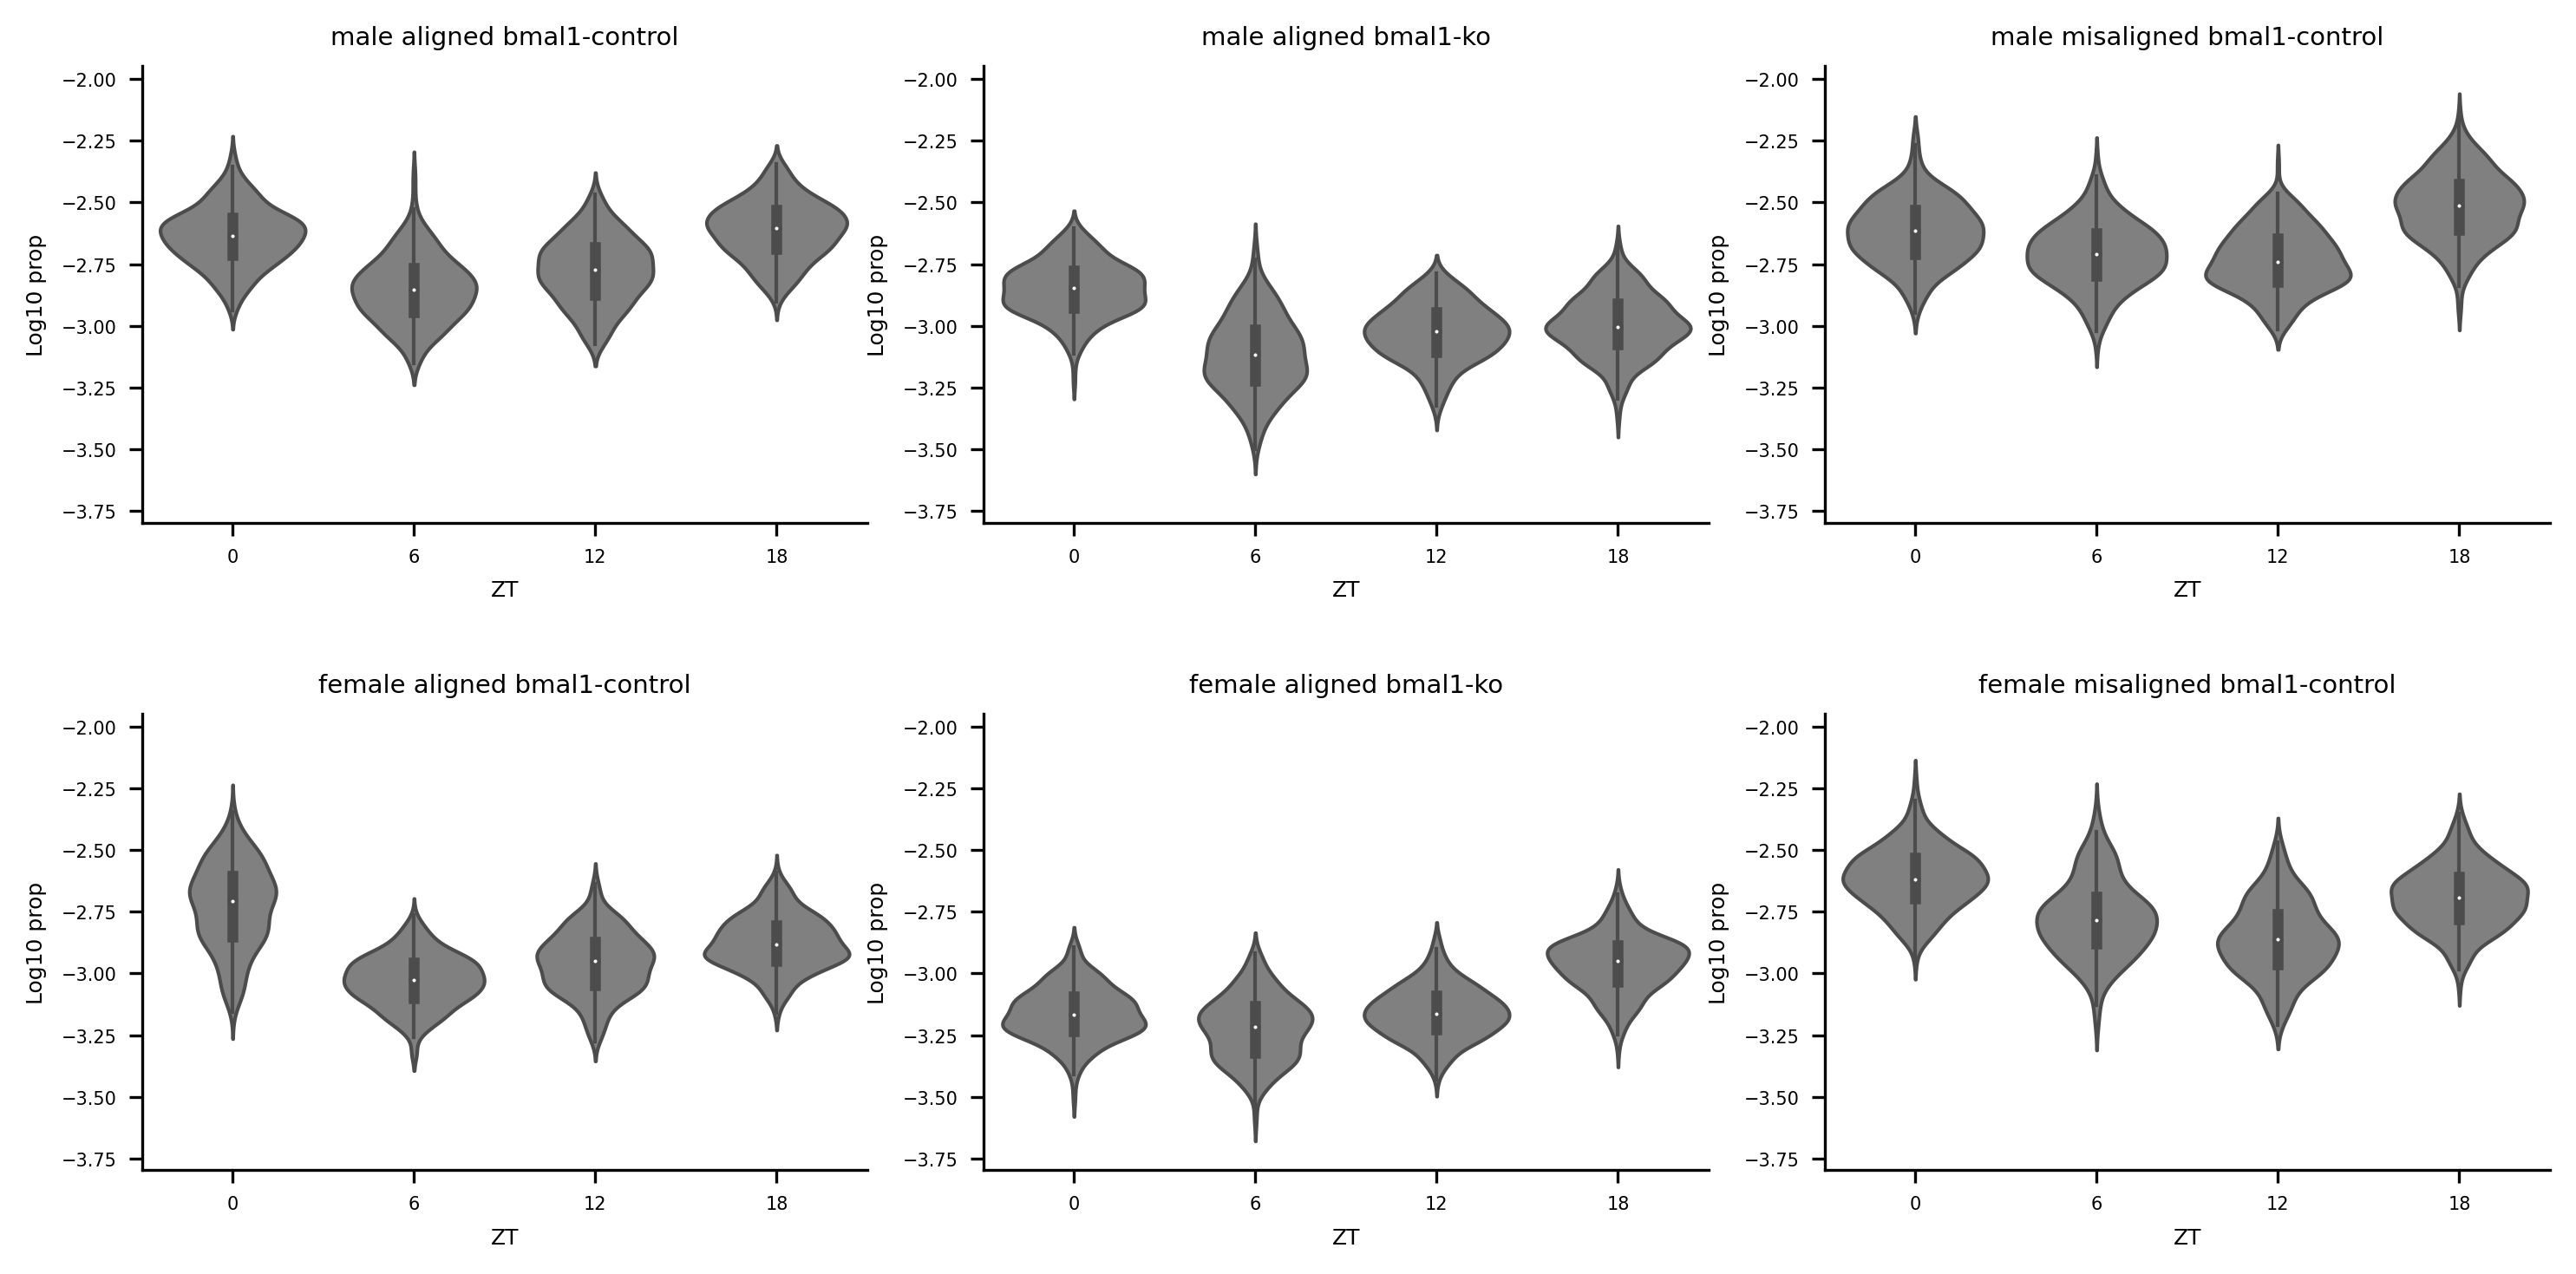

In [232]:
# --- GET SAMPLED WAVEFORMS AND FFT'S  ---




# genes = ['Ccnb1', 'Ccna2', 'Ccnb2', 'Cdc7', 'Cdc20', 'Cdk1']

for gene in genes:
# for gene in ['Smad3']:
    

    print("GENE: %s" % str(gene.capitalize()))
    
    try:



        fig,axs=plt.subplots(figsize=(10,5),nrows=2,ncols=3,dpi=300)

        min_log10_val,max_log10_val = np.inf, -1 * np.inf
        for condit_index, condition in enumerate(descriptions):



            # get the samples log props
            sampled_log_prop,_ = helper_functions.get_log_prop_samples(cluster,condition,num_waveform_samples,cluster_description_folder_out_dict,gene_list=[gene])
            if torch.min(sampled_log_prop).item() / np.log(10) < min_log10_val:
                min_log10_val = torch.min(sampled_log_prop).item() / np.log(10)
            if torch.max(sampled_log_prop).item() / np.log(10) > max_log10_val:
                max_log10_val = torch.max(sampled_log_prop).item() / np.log(10)

            # get the number of grid points
            num_grid_points = sampled_log_prop.shape[1]


            # make gene df
            val_mat = sampled_log_prop[:,:,0]
            time_mat = np.zeros((num_waveform_samples, 4))
            time_mat[:,0] = 0
            time_mat[:,1] = 6
            time_mat[:,2] = 12
            time_mat[:,3] = 18
            gene_df = pd.DataFrame()
            gene_df['ZT'] = time_mat.flatten().astype(int)
            gene_df['Log10 prop'] = val_mat.flatten().numpy() / np.log(10)


            # viz
            sns.despine()
            axs[description_loc_list[condit_index][0],description_loc_list[condit_index][1]] = sns.violinplot(x="ZT", y="Log10 prop", data=gene_df,ax=axs[description_loc_list[condit_index][0],description_loc_list[condit_index][1]],color='0.5')



        # give ourselves some more wiggle room and make title
        margin = 0.2
        max_log10_val = max_log10_val + margin
        min_log10_val = min_log10_val - margin
        for z,condit in enumerate(descriptions):    
            axs[description_loc_list[z][0],description_loc_list[z][1]].set_ylim((min_log10_val,max_log10_val))
            axs[description_loc_list[z][0],description_loc_list[z][1]].set_title(condit)
        fig.tight_layout(h_pad=2, w_pad=0)
        plt.show()
    
    except:
        print("FAILING FOR %s" % (gene))
        pass

    
    
    

In [190]:
cluster = 2

GENE: Uba52


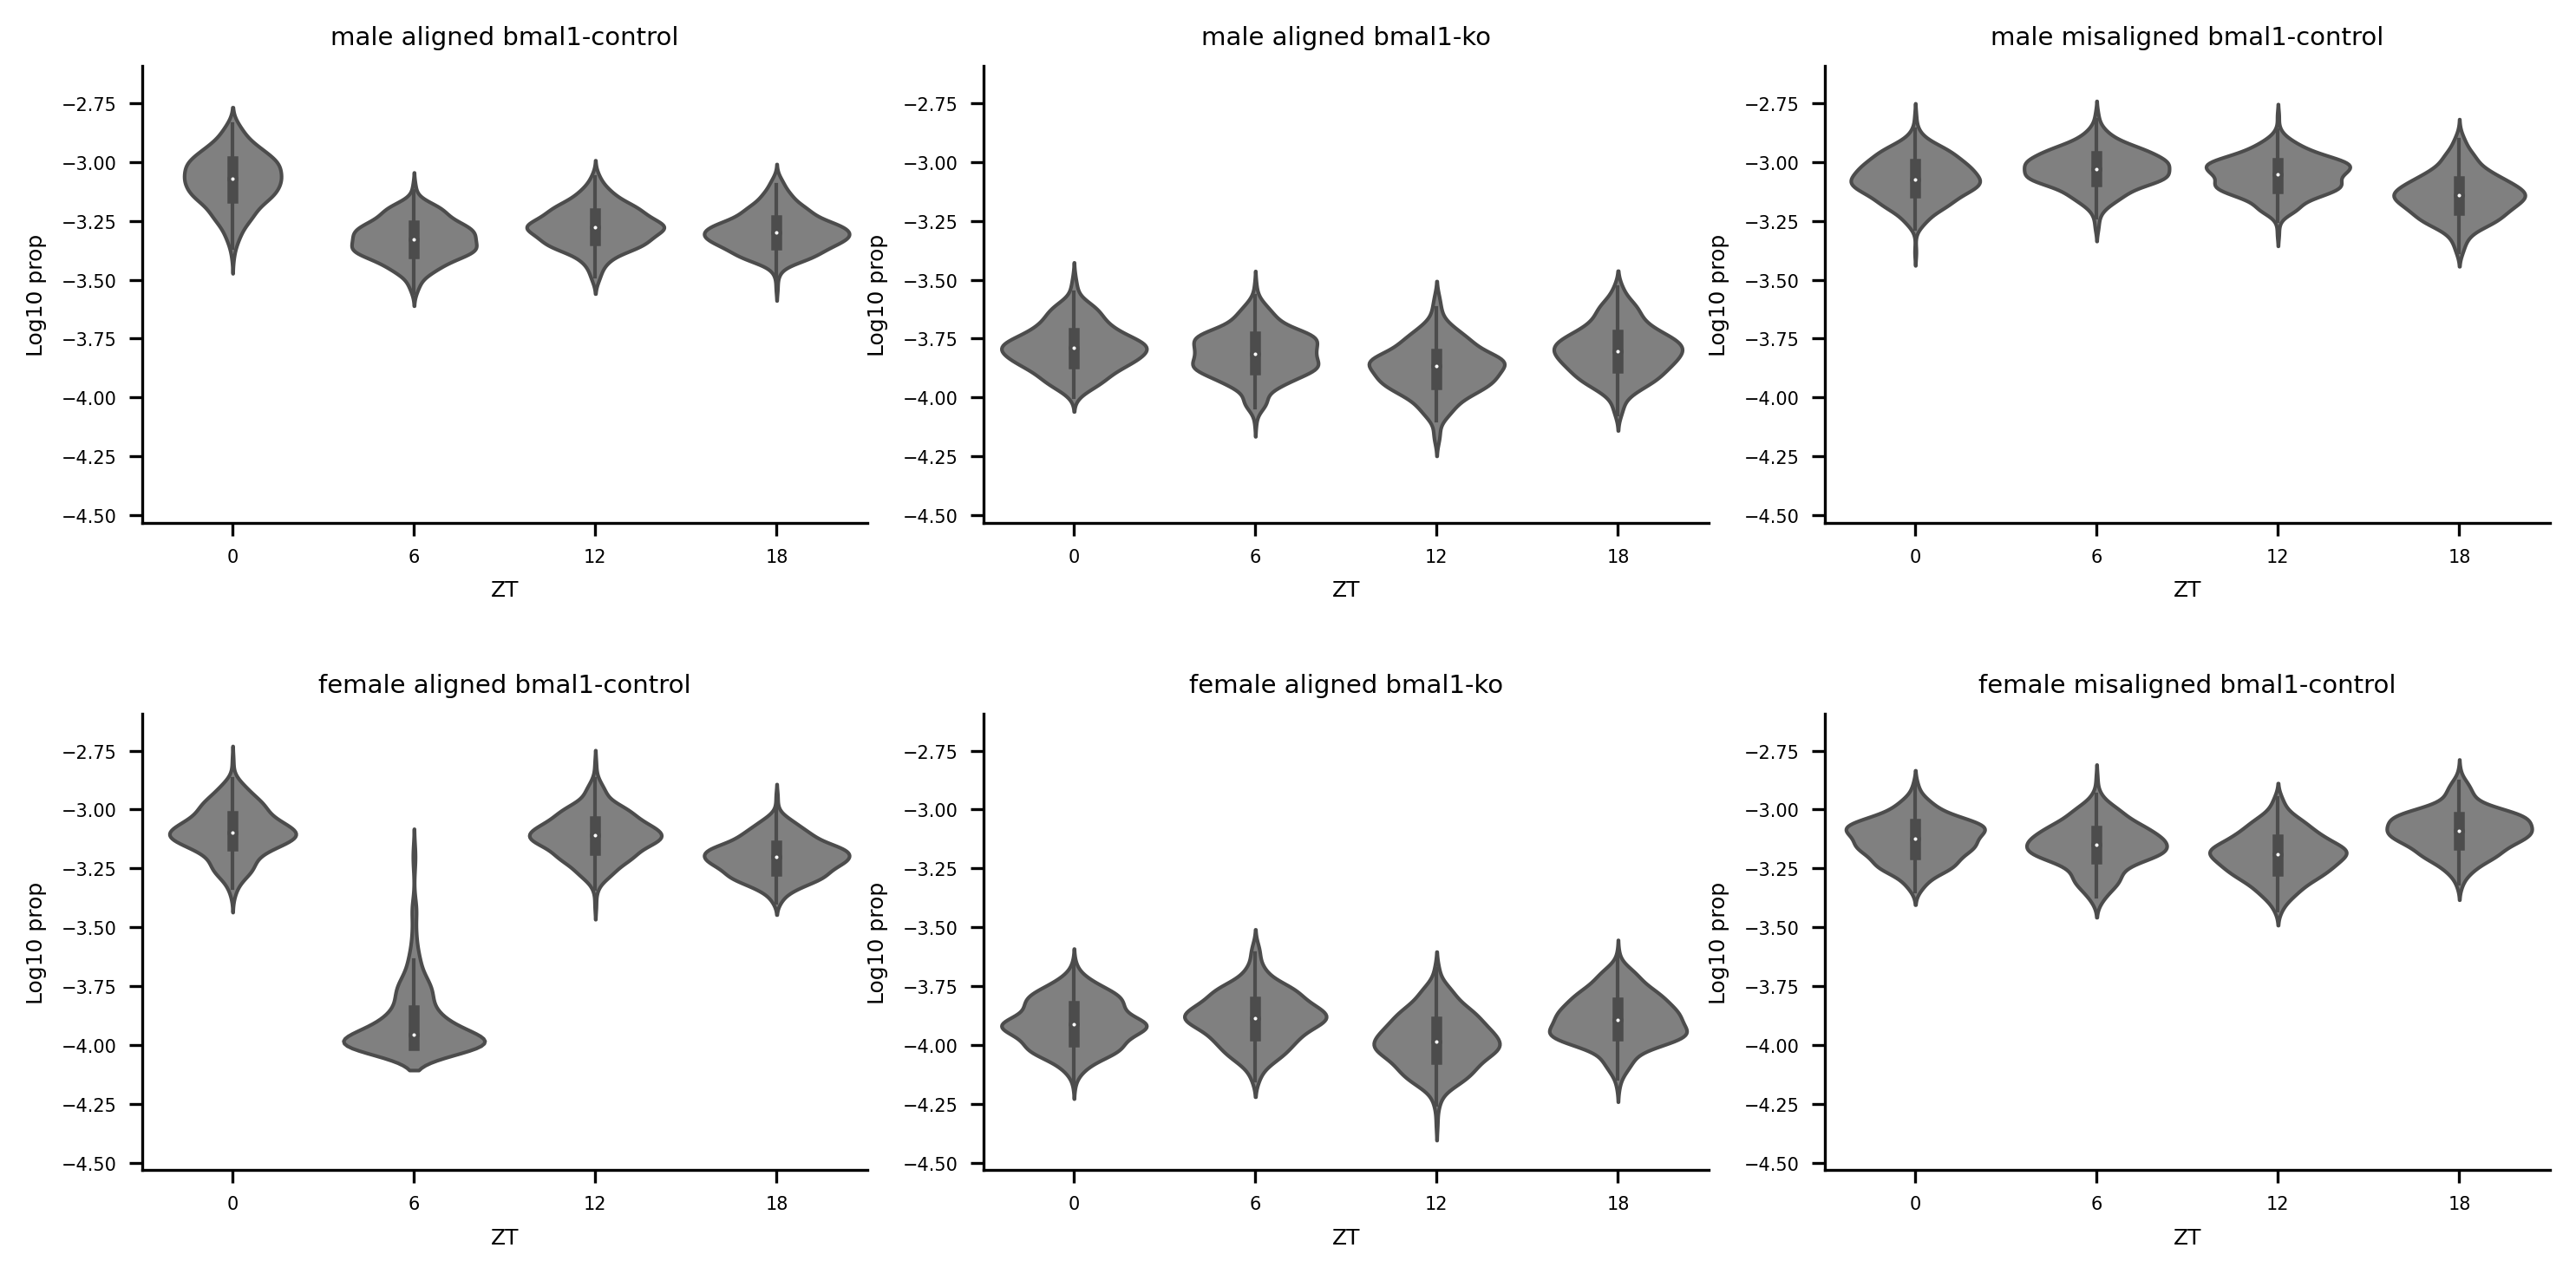

In [191]:
# --- GET SAMPLED WAVEFORMS AND FFT'S  ---




# genes = ['Ccnb1', 'Ccna2', 'Ccnb2', 'Cdc7', 'Cdc20', 'Cdk1']

for gene in genes:
# for gene in ['Smad3']:
    

    print("GENE: %s" % str(gene.capitalize()))
    
    try:



        fig,axs=plt.subplots(figsize=(10,5),nrows=2,ncols=3,dpi=300)

        min_log10_val,max_log10_val = np.inf, -1 * np.inf
        for condit_index, condition in enumerate(descriptions):



            # get the samples log props
            sampled_log_prop,_ = helper_functions.get_log_prop_samples(cluster,condition,num_waveform_samples,cluster_description_folder_out_dict,gene_list=[gene])
            if torch.min(sampled_log_prop).item() / np.log(10) < min_log10_val:
                min_log10_val = torch.min(sampled_log_prop).item() / np.log(10)
            if torch.max(sampled_log_prop).item() / np.log(10) > max_log10_val:
                max_log10_val = torch.max(sampled_log_prop).item() / np.log(10)

            # get the number of grid points
            num_grid_points = sampled_log_prop.shape[1]


            # make gene df
            val_mat = sampled_log_prop[:,:,0]
            time_mat = np.zeros((num_waveform_samples, 4))
            time_mat[:,0] = 0
            time_mat[:,1] = 6
            time_mat[:,2] = 12
            time_mat[:,3] = 18
            gene_df = pd.DataFrame()
            gene_df['ZT'] = time_mat.flatten().astype(int)
            gene_df['Log10 prop'] = val_mat.flatten().numpy() / np.log(10)


            # viz
            sns.despine()
            axs[description_loc_list[condit_index][0],description_loc_list[condit_index][1]] = sns.violinplot(x="ZT", y="Log10 prop", data=gene_df,ax=axs[description_loc_list[condit_index][0],description_loc_list[condit_index][1]],color='0.5')



        # give ourselves some more wiggle room and make title
        margin = 0.2
        max_log10_val = max_log10_val + margin
        min_log10_val = min_log10_val - margin
        for z,condit in enumerate(descriptions):    
            axs[description_loc_list[z][0],description_loc_list[z][1]].set_ylim((min_log10_val,max_log10_val))
            axs[description_loc_list[z][0],description_loc_list[z][1]].set_title(condit)
        fig.tight_layout(h_pad=2, w_pad=0)
        plt.show()
    
    except:
        print("FAILING FOR %s" % (gene))
        pass

    
    
    

In [192]:
sampled_log_prop.shape

torch.Size([300, 4, 1])